In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

# ---------- Norm and Distance Functions ----------
def l1_norm(vector):
    return sum(abs(v) for v in vector)

def l2_norm(vector):
    return sum(v**2 for v in vector)**0.5

def linf_norm(vector):
    return max(abs(v) for v in vector)

def l1_distance(vec1, vec2):
    return l1_norm([vec1[i]-vec2[i] for i in range(len(vec1))])

def l2_distance(vec1, vec2):
    return l2_norm([vec1[i]-vec2[i] for i in range(len(vec1))])

def linf_distance(vec1, vec2):
    return linf_norm([vec1[i]-vec2[i] for i in range(len(vec1))])

# ---------- kNN Function ----------
def knn_predict(test_point, data, labels, k=3, distance_func=l2_distance):
    distances = [(distance_func(test_point, point), labels[i], point) for i, point in enumerate(data)]
    distances.sort(key=lambda x: x[0])
    nearest_labels = [label for (_, label, _) in distances[:k]]
    nearest_points = [pt for (_, _, pt) in distances[:k]]
    pred_label = Counter(nearest_labels).most_common(1)[0][0]
    return pred_label, nearest_points

# ---------- Dataset ----------
X_train = [
    [8, 5], [6, 7], [10, 2], [2, 8], [7, 3]
]
y_train = [1, 1, 0, 0, 1]  # Labels: 1=Specialist, 0=General

X_test = [
    [7, 4], [3, 7]
]

norms = {'L1': l1_distance, 'L2': l2_distance, 'L∞': linf_distance}
k = 3

# ---------- Visualization ----------
for i, test in enumerate(X_test):
    plt.figure(figsize=(10, 4))
    for j, (name, func) in enumerate(norms.items()):
        pred, neighbors = knn_predict(test, X_train, y_train, k=k, distance_func=func)

        plt.subplot(1, 3, j+1)
        # Plot training points
        for x, label in zip(X_train, y_train):
            plt.scatter(x[0], x[1], c='blue' if label==0 else 'green', s=100, edgecolors='k', label='General' if label==0 else 'Specialist')
        # Highlight nearest neighbors
        for n in neighbors:
            plt.scatter(n[0], n[1], s=200, facecolors='none', edgecolors='red', linewidths=2)
        # Plot test point
        plt.scatter(test[0], test[1], c='orange', s=150, marker='*', label='Test Point')

        plt.title(f"Test point {i+1} - {name} distance\nPredicted: {pred}")
        plt.xlim(0,12); plt.ylim(0,10)
        plt.xlabel("Feature 1"); plt.ylabel("Feature 2")
        plt.grid(True)
        plt.legend(loc='upper right')

    plt.tight_layout()
    plt.show()


In [ ]:
# Provider vectors: [specialization, experience, patient rating]
providers = {
    "Provider A": [8, 5, 9],
    "Provider B": [6, 7, 8],
    "Provider C": [10, 2, 7],
    "Provider D": [7, 3, 9]
}

# User preference vector
user_pref = [7, 5, 8]


In [ ]:
def l1_distance(vec1, vec2):
    return sum(abs(vec1[i]-vec2[i]) for i in range(len(vec1)))

def l2_distance(vec1, vec2):
    return sum((vec1[i]-vec2[i])**2 for i in range(len(vec1)))**0.5

def linf_distance(vec1, vec2):
    return max(abs(vec1[i]-vec2[i]) for i in range(len(vec1)))


In [1]:
metrics = {"L1": l1_distance, "L2": l2_distance, "L∞": linf_distance}

for name, func in metrics.items():
    print(f"\nRecommendations using {name} distance:")
    distances = [(prov, func(user_pref, feat)) for prov, feat in providers.items()]
    distances.sort(key=lambda x: x[1])  # smaller distance = more similar
    for prov, dist in distances:
        print(f"  {prov}: distance = {dist}")


NameError: name 'l1_distance' is not defined

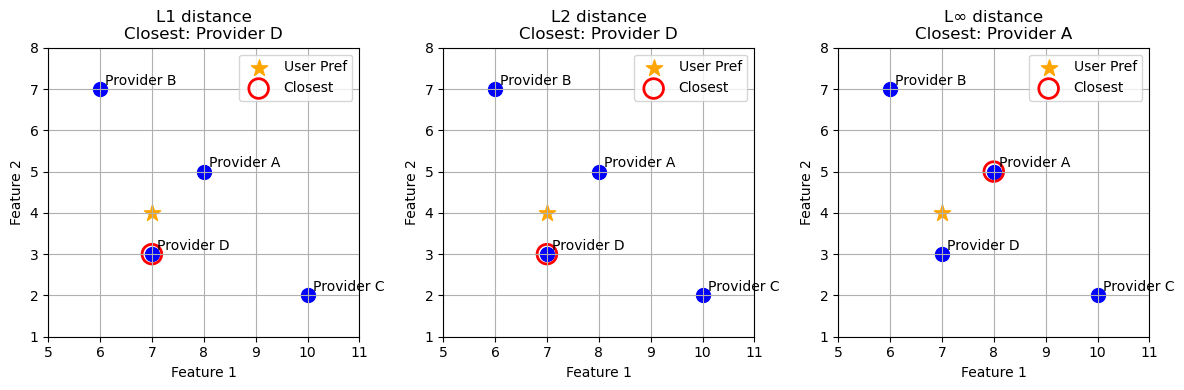

In [2]:
import matplotlib.pyplot as plt

# ---------- Example Providers (2D for plotting) ----------
providers = {
    "Provider A": [8, 5],
    "Provider B": [6, 7],
    "Provider C": [10, 2],
    "Provider D": [7, 3]
}

# User preference vector
user_pref = [7, 4]

# ---------- Distance Functions ----------
def l1_distance(vec1, vec2):
    return sum(abs(vec1[i]-vec2[i]) for i in range(len(vec1)))

def l2_distance(vec1, vec2):
    return sum((vec1[i]-vec2[i])**2 for i in range(len(vec1)))**0.5

def linf_distance(vec1, vec2):
    return max(abs(vec1[i]-vec2[i]) for i in range(len(vec1)))

metrics = {"L1": l1_distance, "L2": l2_distance, "L∞": linf_distance}

# ---------- Visualization ----------
plt.figure(figsize=(12,4))

for i, (name, func) in enumerate(metrics.items()):
    plt.subplot(1,3,i+1)
    
    # Plot providers
    for prov, vec in providers.items():
        plt.scatter(vec[0], vec[1], s=100, c='blue')
        plt.text(vec[0]+0.1, vec[1]+0.1, prov)
    
    # Plot user preference
    plt.scatter(user_pref[0], user_pref[1], s=150, c='orange', marker='*', label='User Pref')
    
    # Compute distances
    distances = [(prov, func(user_pref, vec)) for prov, vec in providers.items()]
    distances.sort(key=lambda x: x[1])
    
    # Highlight closest provider
    closest = distances[0][0]
    closest_vec = providers[closest]
    plt.scatter(closest_vec[0], closest_vec[1], s=200, facecolors='none', edgecolors='red', linewidths=2, label='Closest')
    
    plt.title(f"{name} distance\nClosest: {closest}")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.xlim(5,11)
    plt.ylim(1,8)
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.show()
